# EDA and Data Wrangling for Cleaned Dataset

In [8]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

from scipy import stats

In [9]:
df_clean = pd.read_csv('../datasets/ENB2012_clean.csv')
df_e = pd.read_csv('../datasets/ENB2012_data.csv')

How the heating loads looked before vs after cleaning

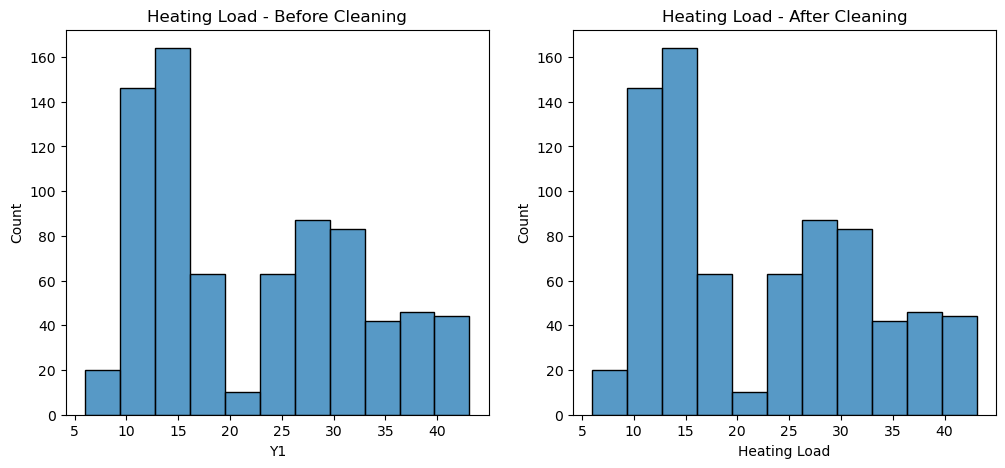

In [10]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
sns.histplot(data = df_e, x = 'Y1', ax = axes[0])
sns.histplot(data = df_clean, x = 'Heating Load', ax = axes[1])
axes[0].set_title("Heating Load - Before Cleaning")
axes[1].set_title("Heating Load - After Cleaning")
plt.show()

How the cooling load looked before vs after cleaning 

Text(0.5, 1.0, 'Cooling Load - After Cleaning')

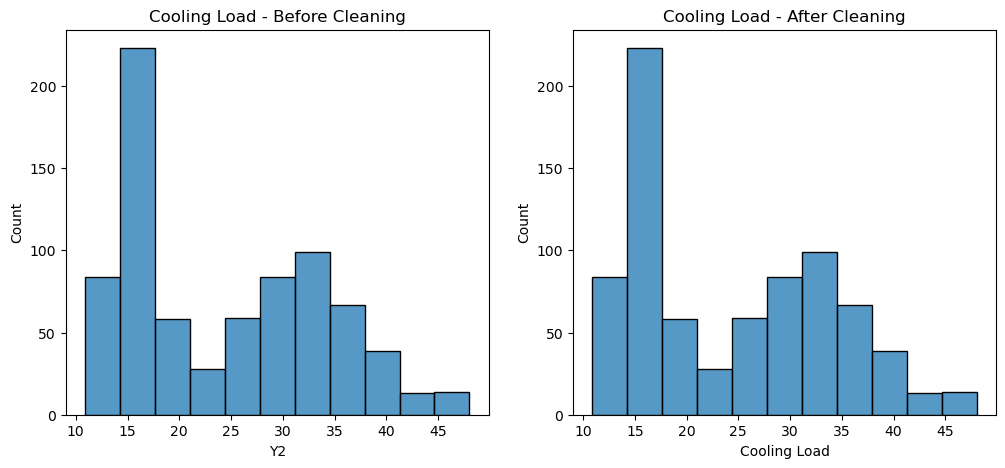

In [12]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
sns.histplot(data = df_e, x = 'Y2', ax = axes[0])
sns.histplot(data = df_clean, x = 'Cooling Load', ax = axes[1])
axes[0].set_title("Cooling Load - Before Cleaning")
axes[1].set_title("Cooling Load - After Cleaning")

How Orientation was affected before vs after cleaning

Text(0.5, 1.0, 'After Cleaning')

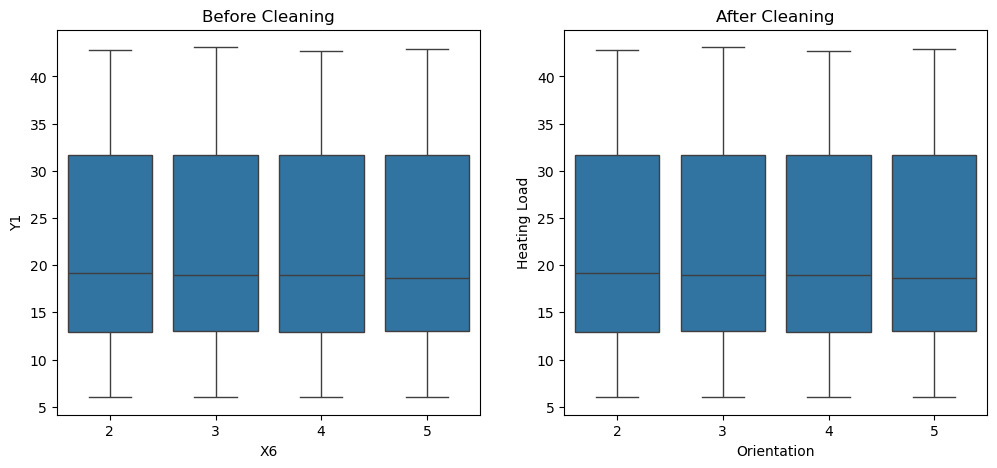

In [15]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
sns.boxplot(data = df_e, x = 'X6', y = 'Y1', ax = axes[0])
sns.boxplot(data = df_clean, x = 'Orientation', y = 'Heating Load', ax = axes[1])
axes[0].set_title('Before Cleaning')
axes[1].set_title('After Cleaning')



How height was affected before vs after cleaning 

Text(0.5, 1.0, 'After Cleaning')

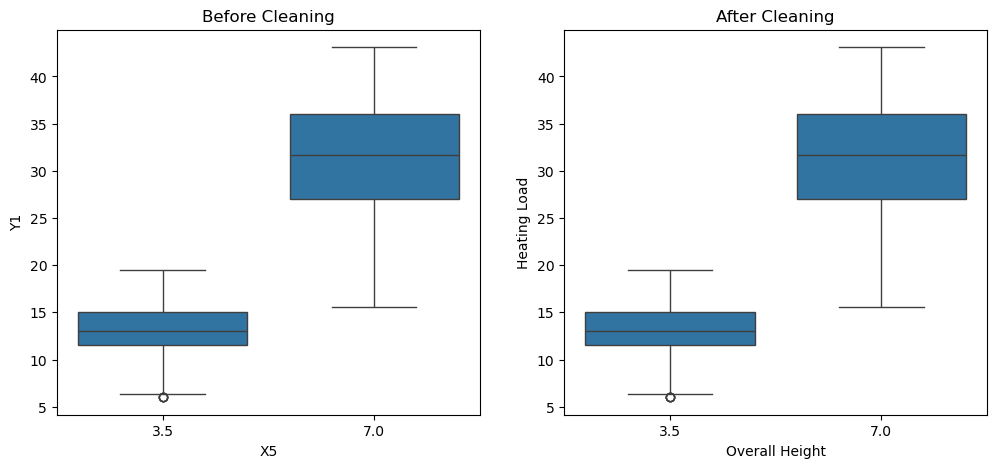

In [16]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
sns.boxplot(data = df_e, x = 'X5', y = 'Y1', ax = axes[0])
sns.boxplot(data = df_clean, x = 'Overall Height', y = 'Heating Load', ax = axes[1])
axes[0].set_title('Before Cleaning')
axes[1].set_title('After Cleaning')

how glazing are distribution was affected before vs after cleaning

Text(0.5, 1.0, 'After Cleaning')

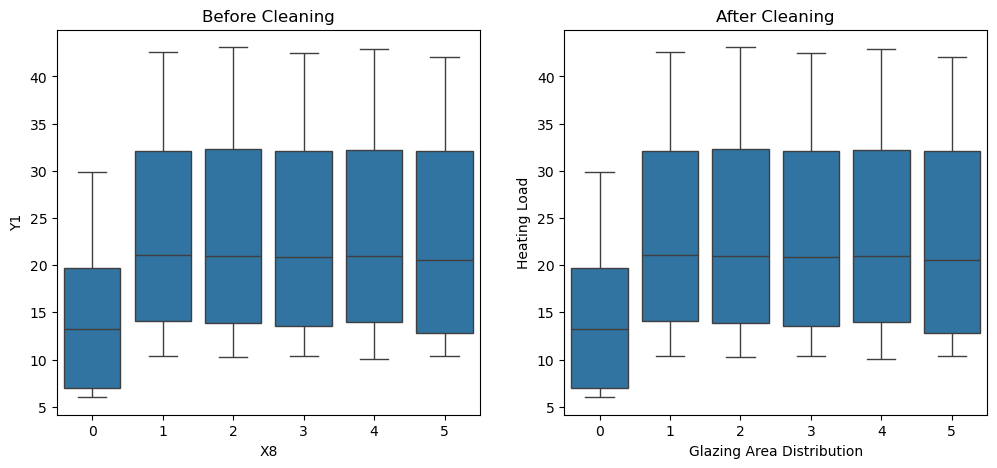

In [17]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
sns.boxplot(data = df_e, x = 'X8', y = 'Y1', ax = axes[0])
sns.boxplot(data = df_clean, x = 'Glazing Area Distribution', y = 'Heating Load', ax = axes[1])
axes[0].set_title('Before Cleaning')
axes[1].set_title('After Cleaning')

how glazing area histogram was affected before vs after cleaning

Text(0.5, 1.0, 'After Cleaning')

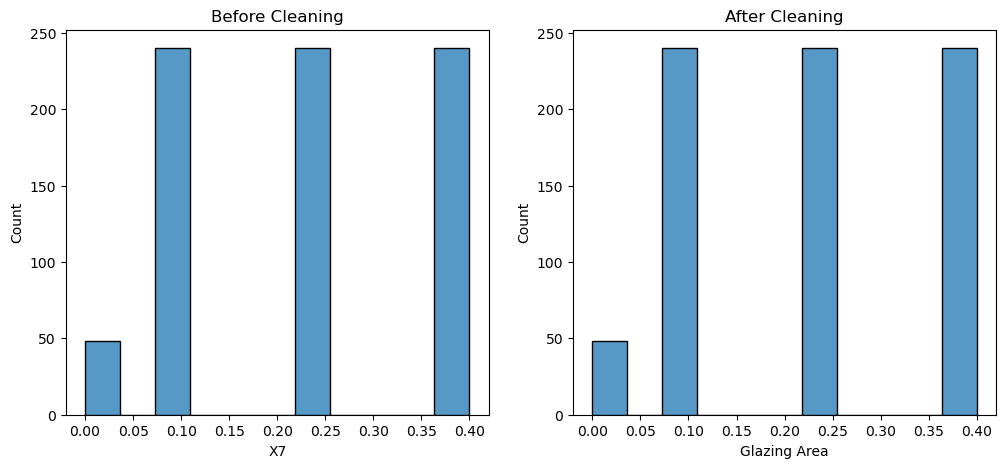

In [18]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
sns.histplot(data = df_e, x = 'X7', ax = axes[0])
sns.histplot(data = df_clean, x = 'Glazing Area', ax = axes[1])
axes[0].set_title('Before Cleaning')
axes[1].set_title('After Cleaning')

Glazing Area vs Energy Loads Boxplot

Text(0.5, 1.0, 'After Cleaning')

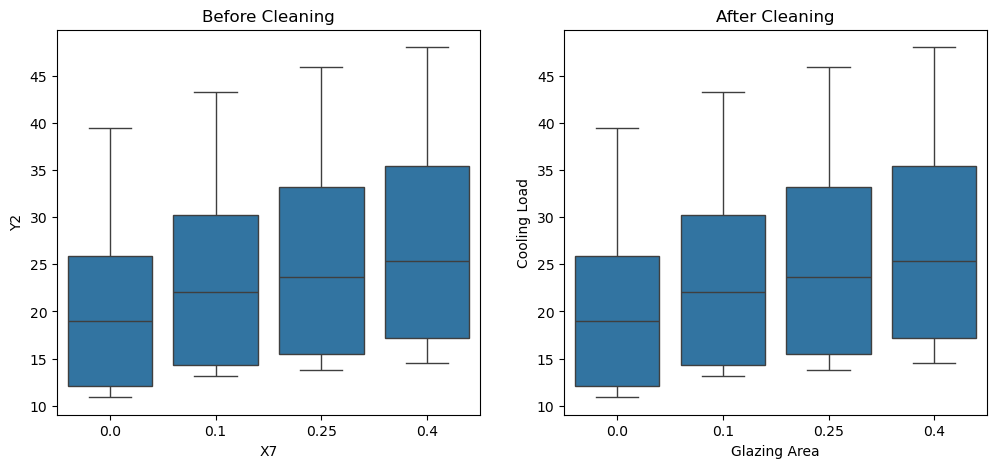

In [19]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
sns.boxplot(data = df_e, x = 'X7', y = 'Y2', ax = axes[0])
sns.boxplot(data = df_clean, x = 'Glazing Area', y = 'Cooling Load', ax = axes[1])
axes[0].set_title('Before Cleaning')
axes[1].set_title('After Cleaning')

Relative Compactness Histogram different from before cleaning vs after. 

Text(0.5, 1.0, 'After Cleaning')

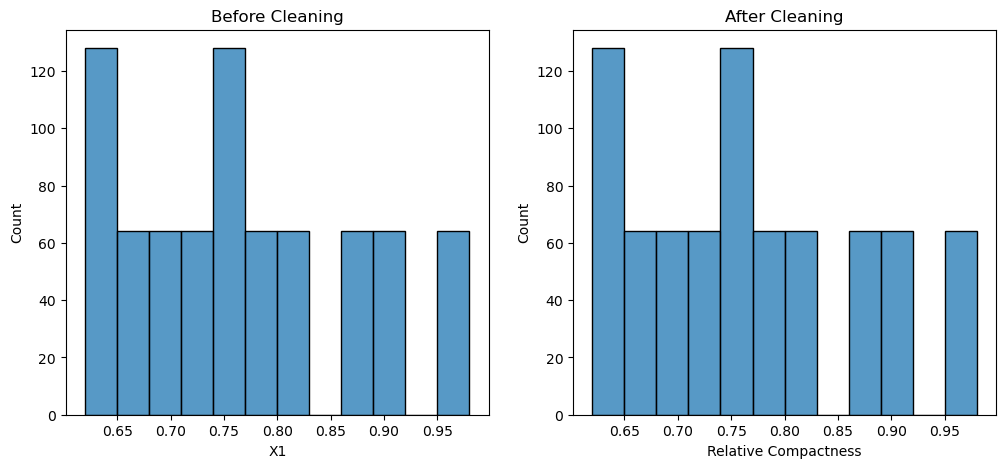

In [20]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
sns.histplot(data = df_e, x = 'X1', ax = axes[0])
sns.histplot(data = df_clean, x = 'Relative Compactness', ax = axes[1])
axes[0].set_title('Before Cleaning')
axes[1].set_title('After Cleaning')

# Into EDA Analysis: 
- From what I have noticed so far from before vs after I have cleaned the data is that there is no difference. This could be because I did not find any irrelevant columns that I would need to drop, didnt have any missing values that I needed to handle, and didnt have obvious data entry errors. 
- Now I am going to continue to perform my EDA using different graphs that I did not use before to gain a better understand of data visually. 


Correlation Heatmap 

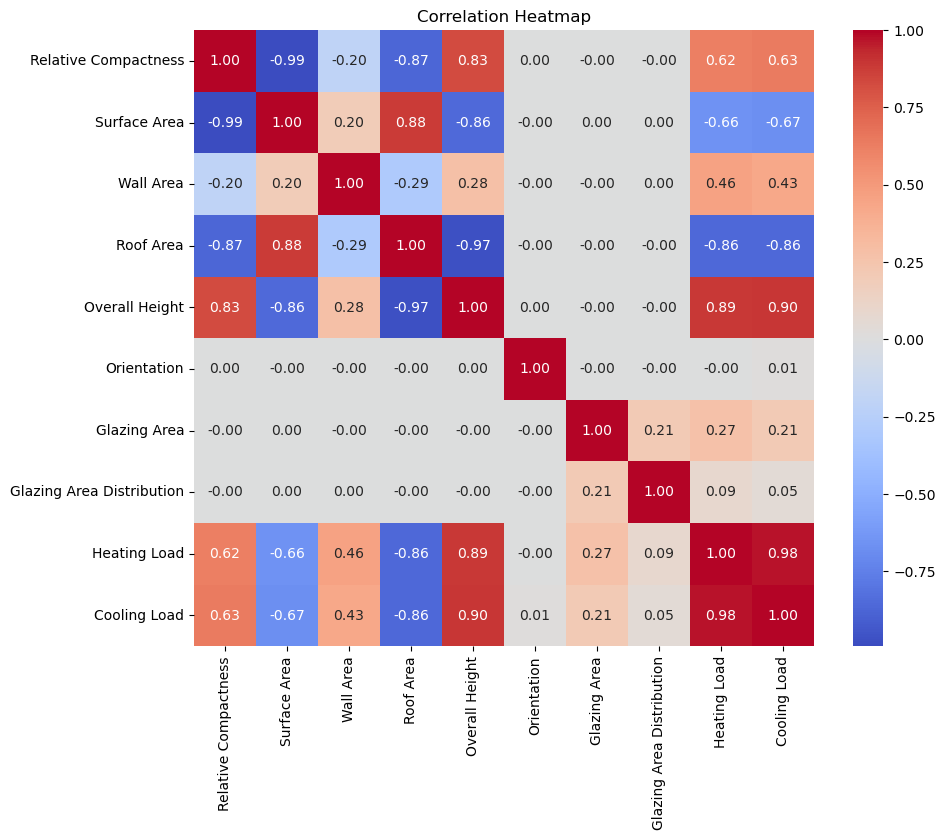

In [21]:
plt.figure(figsize = (10, 8))
sns.heatmap(df_clean.corr(numeric_only = True), annot = True, fmt = '.2f', cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Skewness of the data. Are any features heavily skewed?

In [22]:
print(df_clean.skew(numeric_only = True))

Relative Compactness         0.495513
Surface Area                -0.125131
Wall Area                    0.533417
Roof Area                   -0.162764
Overall Height               0.000000
Orientation                  0.000000
Glazing Area                -0.060254
Glazing Area Distribution   -0.088689
Heating Load                 0.360449
Cooling Load                 0.395992
dtype: float64


Scatter plot vs heating load. This is to see which features most strongly predict heating load. 

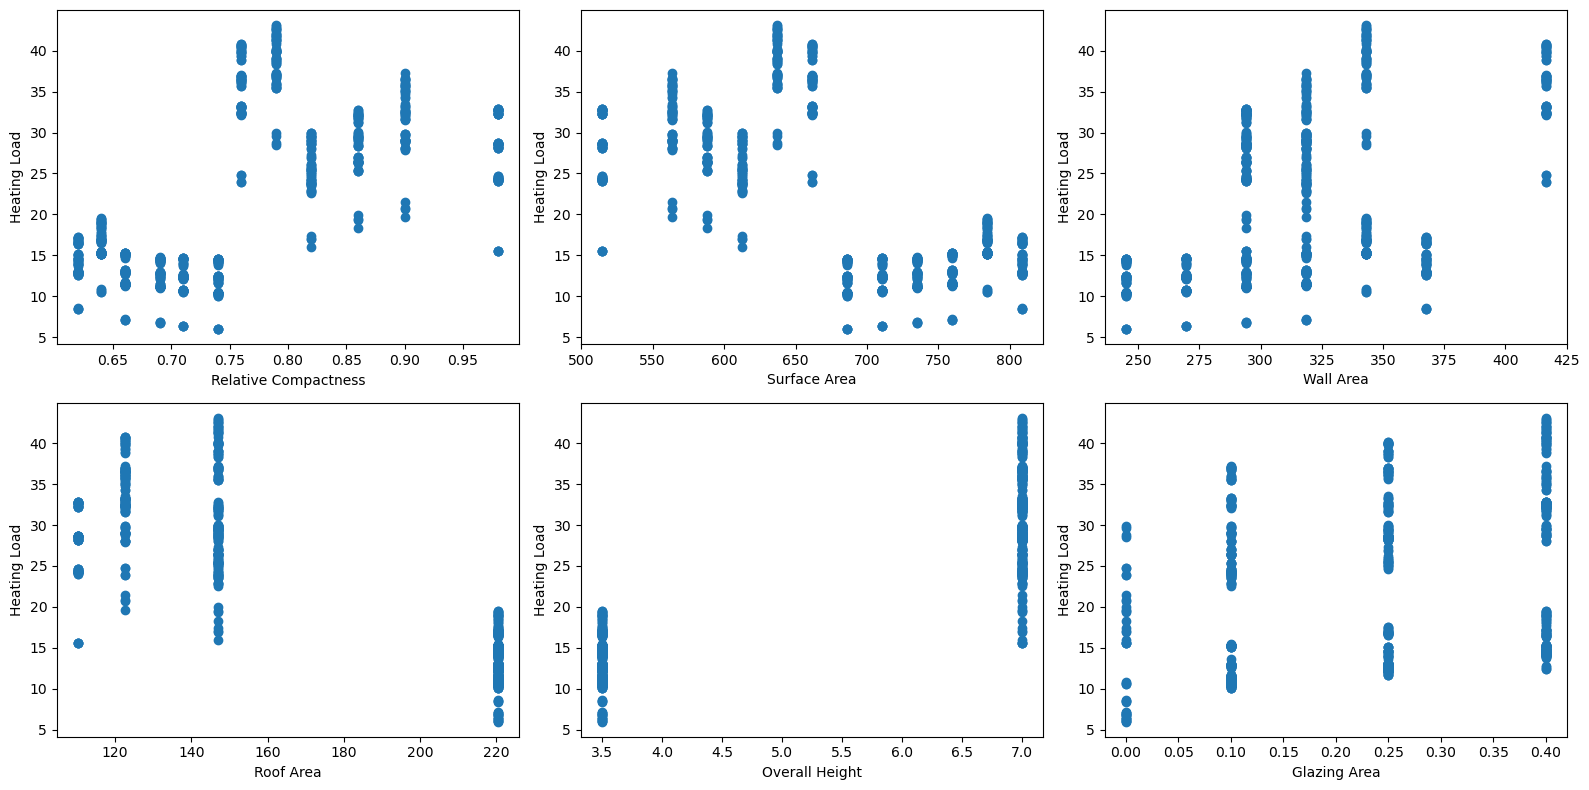

In [25]:
fig, axes = plt.subplots(2, 3, figsize = (16, 8))
axes = axes.flatten()

for i, col in enumerate(df_clean.select_dtypes(include='float64').columns.drop(['Heating Load', 'Cooling Load'])):
    axes[i].scatter(df_clean[col], df_clean['Heating Load'])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Heating Load')

plt.tight_layout()
plt.show()

Scatter Plot vs Cooling Load. Which features most strongly predict Cooling Load? 

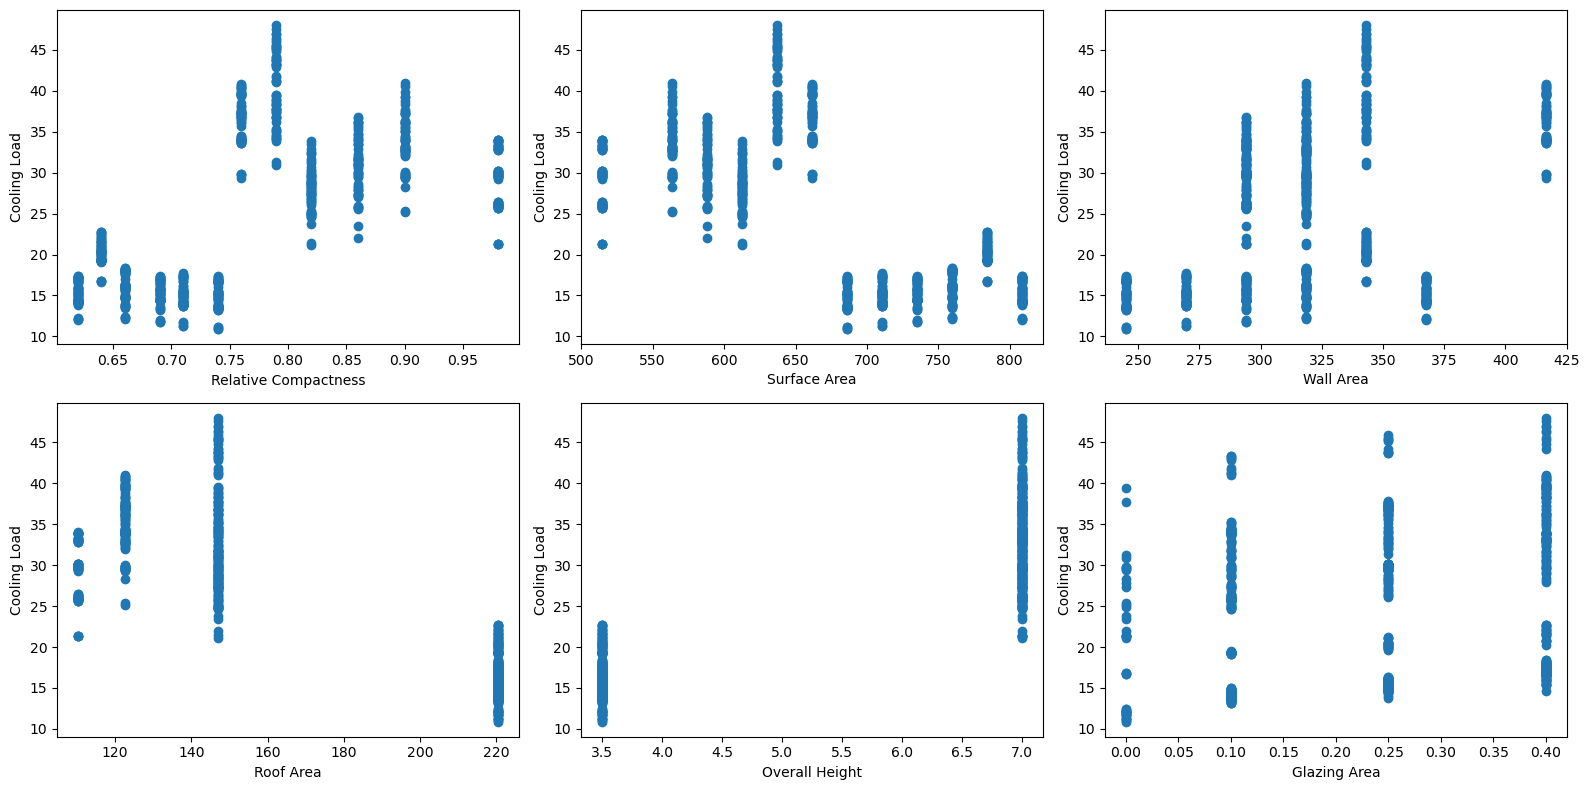

In [26]:
fig, axes = plt.subplots(2, 3, figsize = (16, 8))
axes = axes.flatten()

for i, col in enumerate(df_clean.select_dtypes(include='float64').columns.drop(['Heating Load', 'Cooling Load'])):
    axes[i].scatter(df_clean[col], df_clean['Cooling Load'])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Cooling Load')

plt.tight_layout()
plt.show()

Pairplot. Relationships between all numerical features at once. 

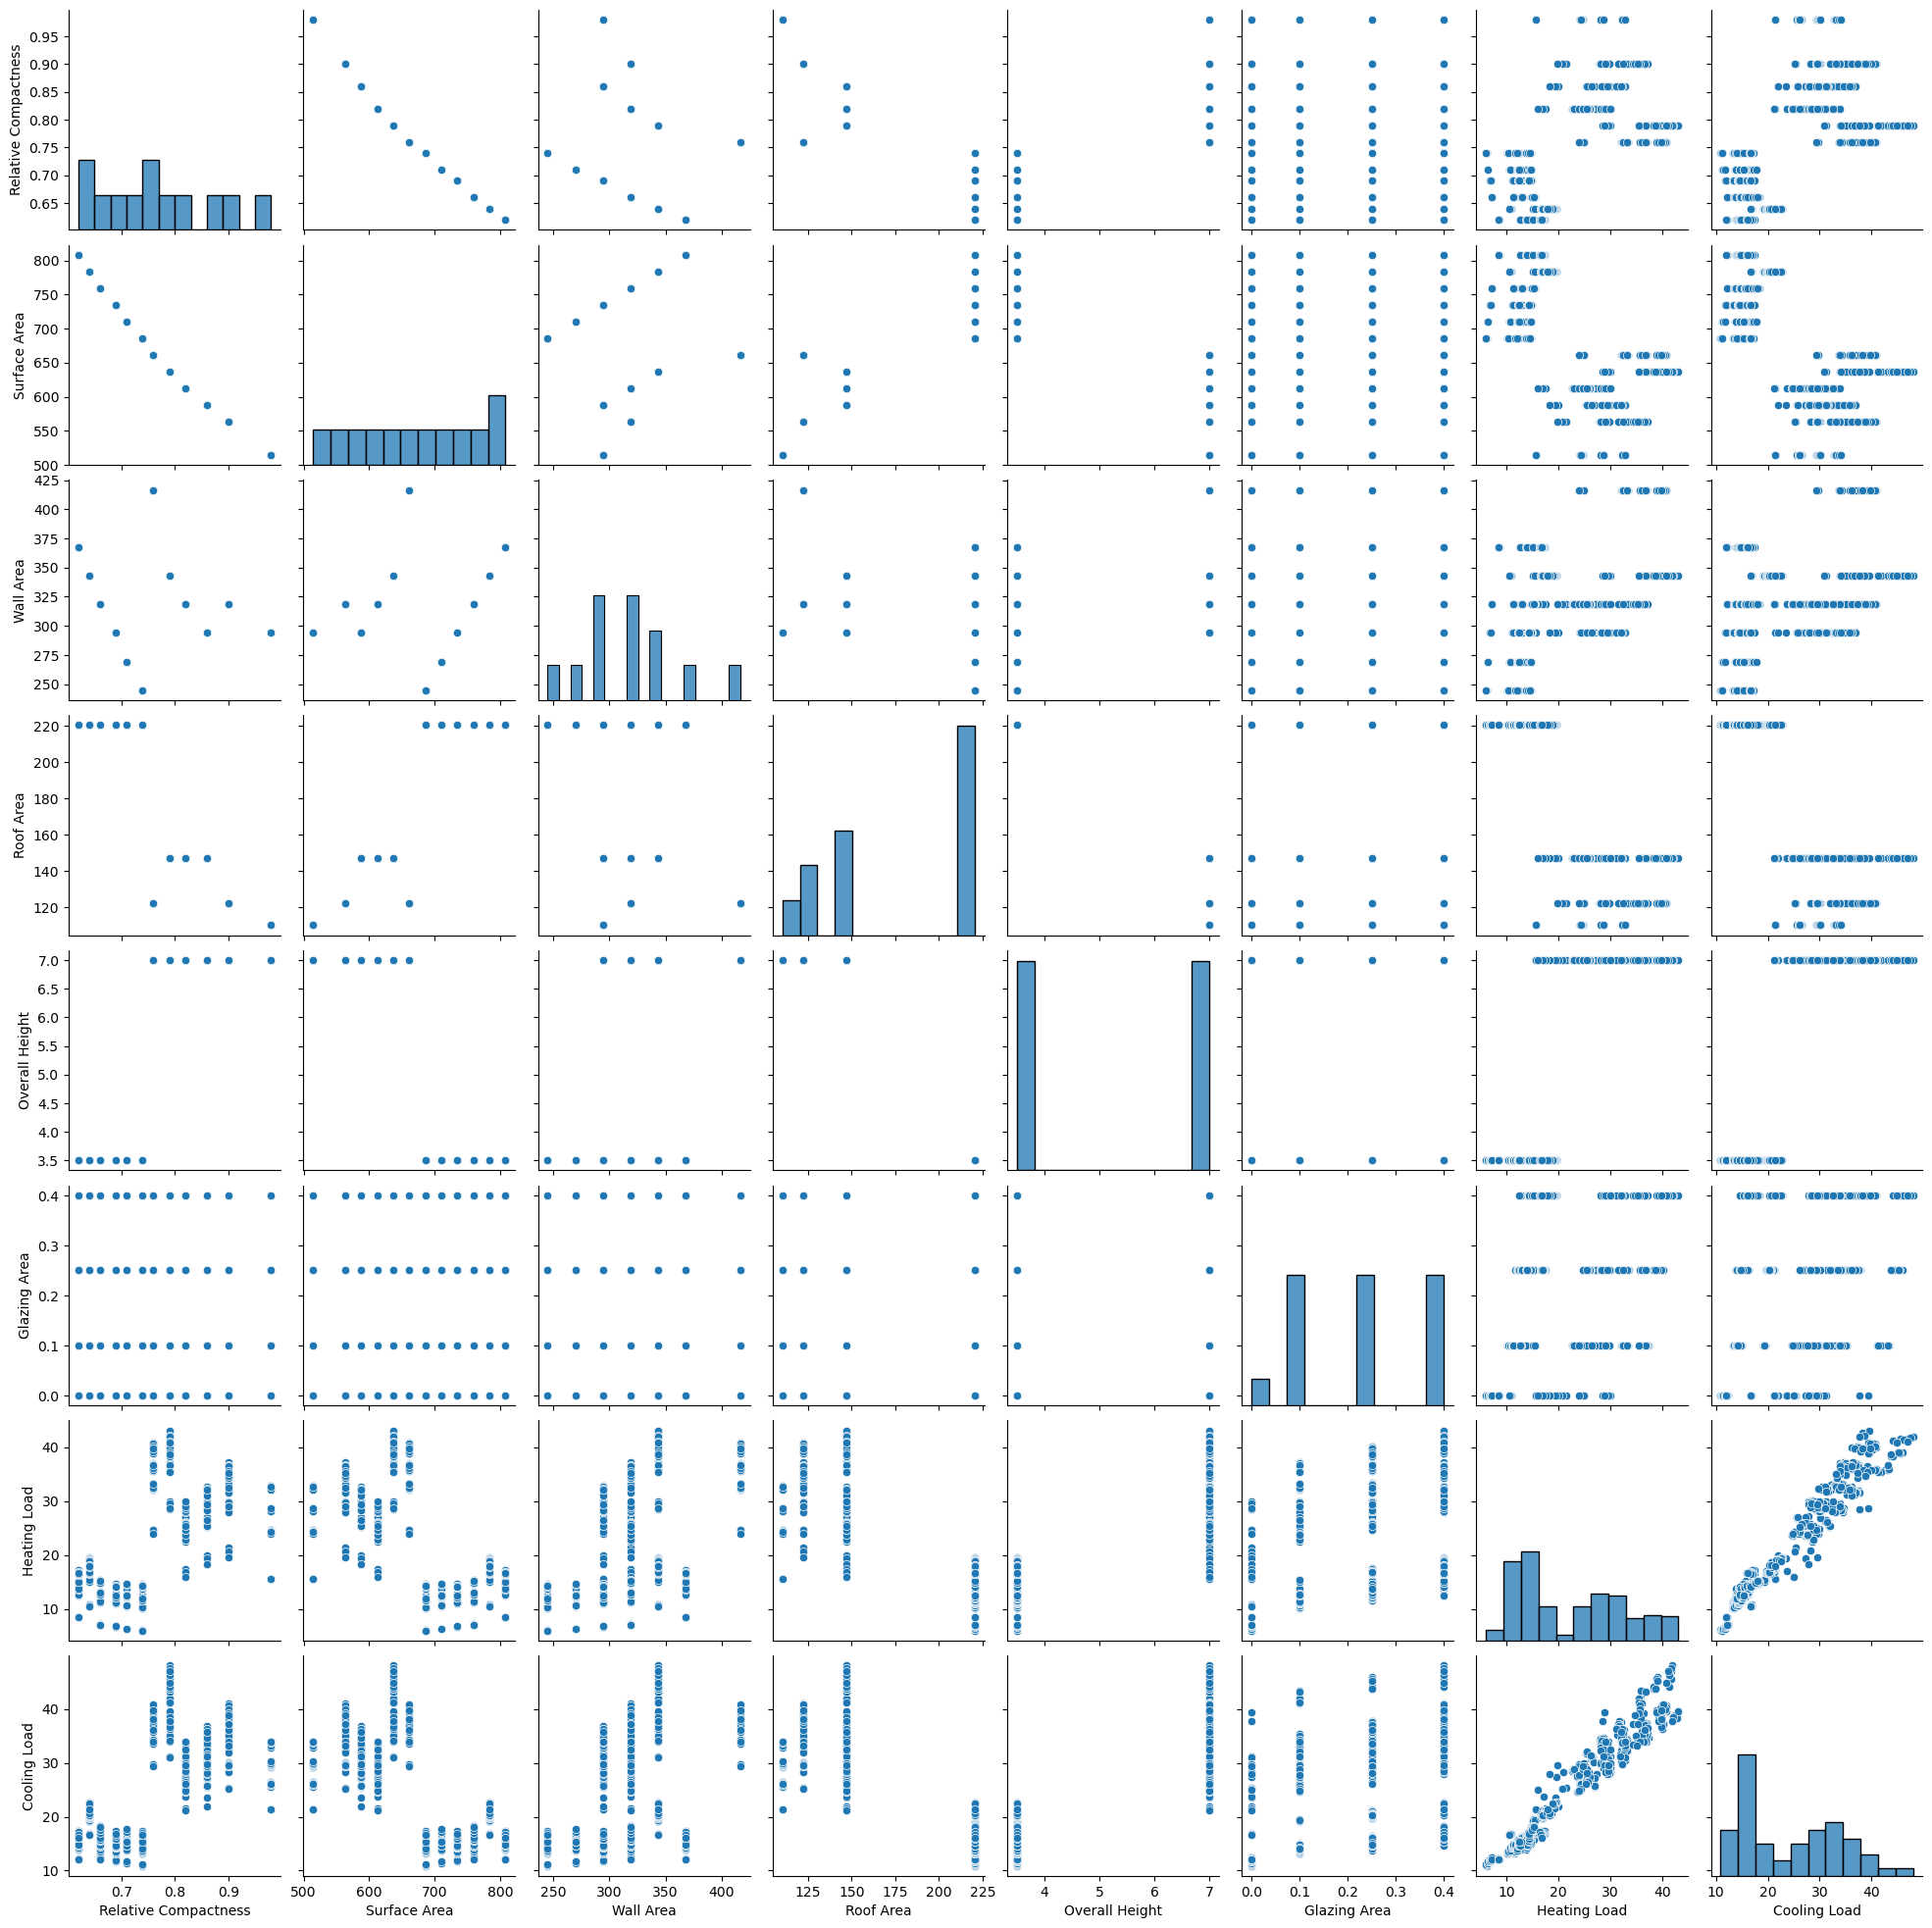

In [27]:
sns.pairplot(df_clean.select_dtypes(include = 'float64'))
plt.show()